# Customer Segmentation in E-commerce

En el entorno ecommerce, no todos los clientes aportan valor ni se comportan de la misma forma.
Algunos compran de manera recurrente, otros concentran su gasto en pocos pedidos, mientras que otros dependen fuertemente de promociones o servicios de conveniencia.

Este notebook presenta un análisis de **segmentación de clientes** a partir de variables agregadas de comportamiento, valor y sensibilidad al precio, con el objetivo de identificar **tipologías de clientes con patrones de compra diferenciados**.

El foco del análisis no está en la construcción de modelos complejos, sino en la **interpretación de los resultados** para **hallar patrones** y poder extraer conclusiones accionables desde un punto de vista de negocio.


## 01. Carga del dataset

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")

### Dataset utilizado

El dataset utilizado contiene información **agregada a nivel cliente**, donde cada fila representa un cliente único y sus métricas de comportamiento histórico en la plataforma de ecommerce.

Las variables incluyen información relacionada con:
- Frecuencia y valor de compra
- Recencia y fidelización
- Sensibilidad a promociones y precios
- Yipo de cesta y uso del servicio

Este enfoque agregado permite centrar el análisis en el **comportamiento global del cliente**, en lugar de analizar pedidos individuales.


In [ ]:
# Cargar dataset
df = pd.read_csv("../data/customers.csv")

# Vista rápida
df.head()

,customer_id,num_orders,avg_order_value,total_spent,days_between_orders,last_purchase_days,active_months,repeat_ratio,discount_ratio,avg_discount_pct,promo_response,price_variability,avg_items_per_order,categories_count,fresh_ratio,private_label_ratio,express_orders_ratio,delivery_preference,online_only,returns_ratio
0,C0001,3,92.91,278.73,26.4,36.6,5,0.38,0.04,0.5,0.90,0.19,9,8,0.75,0.23,0.00,1,1,0.028
1,C0002,19,18.32,348.01,59.3,9.9,5,0.75,0.61,9.7,0.80,0.23,5,3,0.17,0.25,0.74,0,1,0.004
2,C0003,11,55.32,608.55,34.7,46.4,5,0.75,0.40,6.3,0.30,0.14,5,4,0.33,0.28,0.30,0,0,0.038
3,C0004,11,24.09,264.98,32.7,46.6,3,0.48,0.73,16.2,0.92,0.10,21,9,0.46,0.37,0.40,0,0,0.032
4,C0005,28,17.13,479.63,23.0,35.8,6,0.63,0.64,7.3,0.72,0.23,5,9,0.74,0.32,0.30,1,0,0.035


## 02. Exploración Inicial

Antes de aplicar técnicas de segmentación, se realiza una exploración inicial del dataset con el objetivo de validar su estructura y detectar posibles patrones generales de comportamiento.

Esta fase no pretende un análisis exhaustivo, sino confirmar la existencia de heterogeneidad entre clientes en términos de gasto, frecuencia de compra y sensibilidad a promociones, lo que justifica el uso posterior de técnicas de clustering.

In [ ]:
# Dimensiones y columnas
print("Filas, columnas:", df.shape)
df.columns

Filas, columnas: (500, 20)


Index(['customer_id', 'num_orders', 'avg_order_value', 'total_spent',
       'days_between_orders', 'last_purchase_days', 'active_months',
       'repeat_ratio', 'discount_ratio', 'avg_discount_pct', 'promo_response',
       'price_variability', 'avg_items_per_order', 'categories_count',
       'fresh_ratio', 'private_label_ratio', 'express_orders_ratio',
       'delivery_preference', 'online_only', 'returns_ratio'],
      dtype='str')

In [ ]:
# Tipos y valores nulos
df.info()

print("\nNulos por columna:")
display(df.isna().sum().sort_values(ascending=False).head(10))

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           500 non-null    str    
 1   num_orders            500 non-null    int64  
 2   avg_order_value       500 non-null    float64
 3   total_spent           500 non-null    float64
 4   days_between_orders   500 non-null    float64
 5   last_purchase_days    500 non-null    float64
 6   active_months         500 non-null    int64  
 7   repeat_ratio          500 non-null    float64
 8   discount_ratio        500 non-null    float64
 9   avg_discount_pct      500 non-null    float64
 10  promo_response        500 non-null    float64
 11  price_variability     500 non-null    float64
 12  avg_items_per_order   500 non-null    int64  
 13  categories_count      500 non-null    int64  
 14  fresh_ratio           500 non-null    float64
 15  private_label_ratio   500 non-null

customer_id            0
num_orders             0
avg_order_value        0
total_spent            0
days_between_orders    0
last_purchase_days     0
active_months          0
repeat_ratio           0
discount_ratio         0
avg_discount_pct       0
dtype: int64

In [ ]:
# Resumen numérico (excluye customer_id si es string)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,500.0,17.320000,8.582594,2.00,11.0000,18.000,24.000,34.00
avg_order_value,500.0,42.660580,37.369077,15.15,20.6700,25.415,48.555,176.68
total_spent,500.0,498.230680,143.471722,186.54,388.7175,499.120,598.615,887.47
days_between_orders,500.0,31.872000,16.766806,3.00,18.0250,31.850,47.200,59.90
last_purchase_days,500.0,30.664800,16.668376,1.00,17.2000,30.700,44.575,59.80
active_months,500.0,3.466000,1.746696,1.00,2.0000,3.000,5.000,6.00
repeat_ratio,500.0,0.603300,0.170562,0.30,0.4600,0.600,0.750,0.90
discount_ratio,500.0,0.568940,0.281574,0.00,0.3100,0.680,0.800,0.94
avg_discount_pct,500.0,9.917800,5.526187,0.10,5.4000,10.000,14.400,21.30
promo_response,500.0,0.528340,0.249855,0.11,0.3200,0.520,0.760,0.95


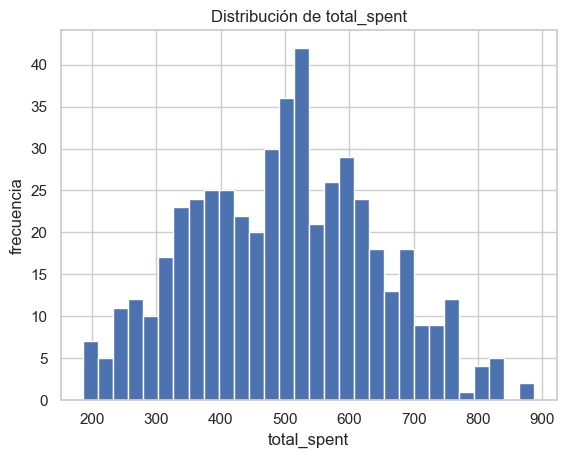

In [ ]:
# Distribución de gasto total
plt.figure()
plt.hist(df["total_spent"], bins=30)
plt.title("Distribución de total_spent")
plt.xlabel("total_spent")
plt.ylabel("frecuencia")
plt.show()

La distribución del gasto total no es homogénea. La mayoría de clientes se concentra en rangos medios de gasto, mientras que existe una minoría de clientes de alto valor que concentra un gasto significativamente superior.

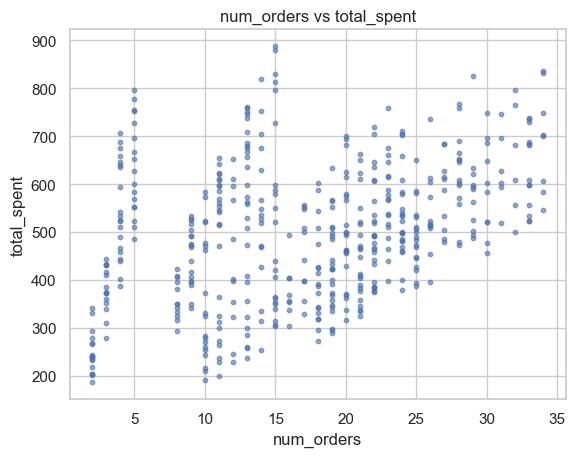

In [ ]:
# Relación: num_orders vs total_spent
plt.figure()
plt.scatter(df["num_orders"], df["total_spent"], s=10, alpha=0.6)
plt.title("num_orders vs total_spent")
plt.xlabel("num_orders")
plt.ylabel("total_spent")
plt.show()

Aunque existe una relación clara entre el número de pedidos y el gasto total, se observan patrones diferenciados: algunos clientes concentran su gasto en pocos pedidos de alto valor, mientras que otros realizan compras frecuentes de menor importe.

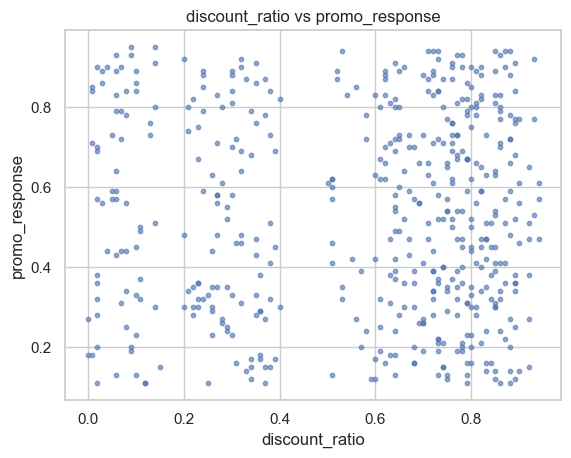

In [ ]:
# Sensibilidad a promociones: discount_ratio vs promo_response
plt.figure()
plt.scatter(df["discount_ratio"], df["promo_response"], s=10, alpha=0.6)
plt.title("discount_ratio vs promo_response")
plt.xlabel("discount_ratio")
plt.ylabel("promo_response")
plt.show()

La relación entre el uso de descuentos y la respuesta a promociones muestra una elevada heterogeneidad, lo que indica distintos niveles de sensibilidad al precio entre los clientes.

### Síntesis de la exploración

La exploración inicial del dataset confirma una elevada heterogeneidad en el comportamiento de los clientes. 
Se observan diferencias claras en el nivel de gasto, en la relación entre frecuencia y valor de compra, así como en la sensibilidad a descuentos y promociones.

Estos patrones sugieren la existencia de **tipologías de clientes diferenciadas**, lo que justifica el uso posterior de técnicas de segmentación para su análisis.

## 03. Preparación y escalado

Antes de aplicar técnicas de reducción de dimensionalidad y clustering, es necesario preparar el dataset para garantizar que todas las variables contribuyen de forma equilibrada al análisis.

El dataset incluye variables con escalas muy diferentes, como importes monetarios, ratios y recuentos. Sin un proceso de escalado previo, aquellas variables con mayor magnitud podrían dominar el análisis y distorsionar los resultados.

Por este motivo, seleccionamos únicamente las variables numéricas relevantes y se aplica un proceso de estandarización, asegurando que todas las variables tengan media cero y varianza unitaria.

In [ ]:
# Columnas a excluir
cols_to_exclude = [
    "customer_id"
]

# Dataset para clustering
df_cluster = df.drop(columns=cols_to_exclude)

df_cluster.head()

,num_orders,avg_order_value,total_spent,days_between_orders,last_purchase_days,active_months,repeat_ratio,discount_ratio,avg_discount_pct,promo_response,price_variability,avg_items_per_order,categories_count,fresh_ratio,private_label_ratio,express_orders_ratio,delivery_preference,online_only,returns_ratio
0,3,92.91,278.73,26.4,36.6,5,0.38,0.04,0.5,0.90,0.19,9,8,0.75,0.23,0.00,1,1,0.028
1,19,18.32,348.01,59.3,9.9,5,0.75,0.61,9.7,0.80,0.23,5,3,0.17,0.25,0.74,0,1,0.004
2,11,55.32,608.55,34.7,46.4,5,0.75,0.40,6.3,0.30,0.14,5,4,0.33,0.28,0.30,0,0,0.038
3,11,24.09,264.98,32.7,46.6,3,0.48,0.73,16.2,0.92,0.10,21,9,0.46,0.37,0.40,0,0,0.032
4,28,17.13,479.63,23.0,35.8,6,0.63,0.64,7.3,0.72,0.23,5,9,0.74,0.32,0.30,1,0,0.035


In [ ]:
# Seleccionar solo columnas numéricas
X = df_cluster.select_dtypes(include=[np.number])

X.head()

,num_orders,avg_order_value,total_spent,days_between_orders,last_purchase_days,active_months,repeat_ratio,discount_ratio,avg_discount_pct,promo_response,price_variability,avg_items_per_order,categories_count,fresh_ratio,private_label_ratio,express_orders_ratio,delivery_preference,online_only,returns_ratio
0,3,92.91,278.73,26.4,36.6,5,0.38,0.04,0.5,0.90,0.19,9,8,0.75,0.23,0.00,1,1,0.028
1,19,18.32,348.01,59.3,9.9,5,0.75,0.61,9.7,0.80,0.23,5,3,0.17,0.25,0.74,0,1,0.004
2,11,55.32,608.55,34.7,46.4,5,0.75,0.40,6.3,0.30,0.14,5,4,0.33,0.28,0.30,0,0,0.038
3,11,24.09,264.98,32.7,46.6,3,0.48,0.73,16.2,0.92,0.10,21,9,0.46,0.37,0.40,0,0,0.032
4,28,17.13,479.63,23.0,35.8,6,0.63,0.64,7.3,0.72,0.23,5,9,0.74,0.32,0.30,1,0,0.035


In [ ]:
# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos a DataFrame para trabajar cómodo
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,num_orders,avg_order_value,total_spent,days_between_orders,last_purchase_days,active_months,repeat_ratio,discount_ratio,avg_discount_pct,promo_response,price_variability,avg_items_per_order,categories_count,fresh_ratio,private_label_ratio,express_orders_ratio,delivery_preference,online_only,returns_ratio
0,-1.670164,1.346026,-1.531455,-0.326686,0.356432,0.879109,-1.310510,-1.880391,-1.705920,1.488993,-0.325623,-1.057739,1.082349,1.463679,-1.441751,-1.691407,0.926680,0.972381,0.230767
1,0.195941,-0.652009,-1.048089,1.637490,-1.247008,0.879109,0.860958,0.145969,-0.039452,1.088360,0.182369,-1.717383,-1.073725,-1.649618,-1.268589,2.044166,-1.079121,0.972381,-1.390548
2,-0.737112,0.339107,0.769697,0.168836,0.944961,0.879109,0.860958,-0.600585,-0.655320,-0.914805,-0.960614,-1.717383,-0.642510,-0.790778,-1.008845,-0.176985,-1.079121,-1.028403,0.906315
3,-0.737112,-0.497448,-1.627389,0.049433,0.956971,-0.267057,-0.723627,0.572571,1.137944,1.569119,-1.468607,0.921193,1.513564,-0.092969,-0.229613,0.327822,-1.079121,-1.028403,0.500986
4,1.245625,-0.683885,-0.129777,-0.529671,0.308389,1.452192,0.156698,0.252620,-0.474183,0.767853,0.182369,-1.717383,1.513564,1.410002,-0.662520,-0.176985,0.926680,-1.028403,0.703651


El dataset resultante constituye una representación normalizada del comportamiento de los clientes, adecuada para la aplicación de técnicas de reducción de dimensionalidad y segmentación.

## 04. Reducción de dimensionalidad (PCA)

El dataset contiene un número elevado de variables que, en muchos casos, están correlacionadas entre sí. 
Con el objetivo de simplificar el espacio de datos y reducir la complejidad del análisis, se aplica un proceso de **reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA)**.

PCA nos permite transformar las variables originales en un conjunto reducido de componentes no correlacionados, que concentran la mayor parte de la variabilidad presente en los datos. 
Esta transformación facilita la aplicación posterior de técnicas de clustering y mejora la estabilidad de los resultados.

In [ ]:
# PCA sin limitar componentes
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada acumulada
explained_variance = np.cumsum(pca.explained_variance_ratio_)

explained_variance

array([0.21128249, 0.28072978, 0.34767264, 0.41179398, 0.47303276,
       0.5299337 , 0.5847968 , 0.6382325 , 0.6912468 , 0.74041107,
       0.78648181, 0.83223467, 0.87478729, 0.91555289, 0.95544373,
       0.97623657, 0.98731332, 0.9945007 , 1.        ])

### Selección del número de componentes

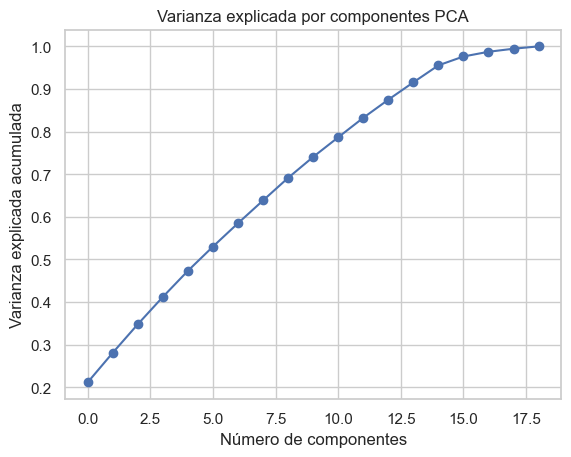

In [ ]:
plt.figure()
plt.plot(explained_variance, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada por componentes PCA")
plt.show()

La varianza explicada acumulada muestra que los primeros componentes concentran la mayor parte de la información del dataset. 
A partir de un determinado número de componentes, el incremento de varianza explicada es progresivamente menor.

Seleccionamos **8 componentes principales**, que explican aproximadamente el 70% de la varianza total, como compromiso entre simplicidad y capacidad explicativa.

In [ ]:
# PCA con número de componentes elegido
n_components = 8
pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

# DataFrame con componentes
pca_columns = [f"PC{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-3.708817,-0.274950,-0.961985,-1.521609,1.103747,2.799308,-0.367984,0.404041
1,1.112911,1.982177,-1.475424,-0.113021,0.293685,-0.555424,0.541193,1.367083
2,-1.131545,1.047821,1.209174,0.025702,0.626836,-0.097405,2.095252,-0.168157
3,0.699261,-0.084745,-1.166335,-0.375735,-2.054460,1.450173,0.201951,0.235525
4,0.719236,0.848268,-0.547831,-0.609077,1.308446,1.684930,0.361592,0.278233


Los componentes principales obtenidos constituyen una representación compacta del comportamiento de los clientes, adecuada para su posterior agrupación mediante técnicas de clustering.

## 05. Clustering (KMeans)

Una vez obtenida una representación reducida del comportamiento de los clientes mediante PCA, se aplica un algoritmo de clustering con el objetivo de identificar grupos de clientes con patrones similares.

Para ello, utilizamos el algoritmo **KMeans**, una técnica ampliamente empleada en segmentación de clientes por su simplicidad, estabilidad e interpretabilidad, especialmente en contextos de análisis exploratorio y de negocio.

### Selección del número de clusters

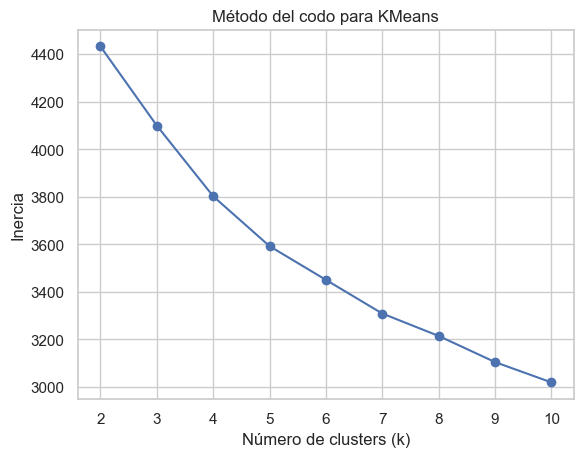

In [ ]:
# Método del codo
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

# Gráfico del codo
plt.figure()
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para KMeans")
plt.show()

El método del codo permite evaluar la evolución de la inercia en función del número de clusters. 
En el gráfico se observa una reducción significativa de la inercia hasta valores de k=4–5, a partir de los cuales las mejoras son progresivamente menores.

En base a este criterio, se selecciona **k = 5** como un compromiso adecuado entre granularidad e interpretabilidad de los segmentos.

### Aplicación del modelo de clustering

In [ ]:
# KMeans final
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(df_pca)

# Añadimos cluster al dataset original
df["cluster"] = clusters

df[["cluster"]].value_counts().sort_index()

cluster
0           69
1          110
2          112
3           97
4          112
Name: count, dtype: int64

Cada cliente queda asignado a uno de los cinco clusters resultantes, que representan distintas tipologías de comportamiento dentro del entorno ecommerce.

## 06. Perfilado de clusters

Una vez asignado cada cliente a un cluster, se procede al análisis de sus características con el objetivo de interpretar los grupos obtenidos y entender las diferencias de comportamiento entre ellos.

El perfilado se realiza a partir de los valores medios de las variables originales para cada cluster, lo que permite identificar patrones de compra, niveles de fidelidad, sensibilidad al precio y uso del servicio asociados a cada segmento.

### Perfilado cuantitativo de los clusters

In [ ]:
# Perfilado por cluster (medias)
cluster_profile = (
    df
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,num_orders,avg_order_value,total_spent,days_between_orders,last_purchase_days,active_months,repeat_ratio,discount_ratio,avg_discount_pct,promo_response,price_variability,avg_items_per_order,categories_count,fresh_ratio,private_label_ratio,express_orders_ratio,delivery_preference,online_only,returns_ratio
cluster,,,,,,,,,,,,,,,,,,,
0,3.54,129.30,459.79,35.02,27.44,3.77,0.56,0.07,1.24,0.55,0.22,14.74,5.22,0.48,0.40,0.00,0.54,0.55,0.03
1,18.57,22.50,405.59,32.43,24.72,3.42,0.64,0.77,13.22,0.59,0.24,18.04,4.64,0.50,0.42,0.42,0.40,0.22,0.02
2,23.65,23.26,537.79,32.93,27.47,4.50,0.66,0.75,13.29,0.52,0.20,13.34,6.18,0.44,0.33,0.45,0.78,0.58,0.02
3,11.35,49.16,557.34,33.64,31.63,3.27,0.62,0.30,5.35,0.50,0.22,15.62,5.57,0.46,0.39,0.20,0.39,0.45,0.03
4,23.42,22.85,522.15,26.79,40.86,2.46,0.52,0.73,12.60,0.48,0.20,15.15,5.74,0.50,0.45,0.46,0.56,0.77,0.03


In [ ]:
# Tamaño de cada cluster
df["cluster"].value_counts(normalize=True).sort_index().round(3)

cluster
0    0.138
1    0.220
2    0.224
3    0.194
4    0.224
Name: proportion, dtype: float64

### Interpretación de los segmentos

#### Cluster 0 – Clientes ocasionales de ticket medio-alto

Este segmento agrupa clientes con un número reducido de pedidos, pero con un importe medio por compra elevado. 
Presentan una baja dependencia de descuentos y promociones, lo que sugiere un comportamiento de compra más puntual y menos sensible al precio.

Se trata de clientes que compran de forma selectiva, probablemente motivados por necesidades concretas o por la búsqueda de calidad, más que por incentivos promocionales.

#### Cluster 1 – Clientes cazadores de promociones

Este cluster está formado por clientes con una frecuencia de compra relativamente alta, pero con un importe medio por pedido bajo. 
Destacan por un uso intensivo de descuentos y una elevada respuesta a promociones, lo que indica una fuerte sensibilidad al precio.

Su comportamiento está claramente condicionado por la existencia de incentivos, lo que los convierte en un segmento activo pero potencialmente volátil si se reducen las promociones.

#### Cluster 2 – Clientes fieles de alto valor

Este segmento representa a los clientes más valiosos del conjunto. 
Combinan una alta frecuencia de compra con un gasto total elevado y una diversificación significativa de categorías.

Presentan un buen nivel de fidelización y una sensibilidad moderada a promociones, lo que sugiere una relación consolidada con la plataforma y un alto potencial estratégico para el negocio.

#### Cluster 3 – Clientes recurrentes de ticket medio

Este cluster agrupa clientes con un comportamiento estable y equilibrado, tanto en frecuencia de compra como en valor medio por pedido. 
No destacan por una sensibilidad extrema al precio ni por un gasto excepcionalmente alto.

Se trata de un segmento consistente, con margen para estrategias de incremento de cesta media o cross-selling.

#### Cluster 4 – Clientes intensivos en servicio y conveniencia

Este segmento está compuesto por clientes muy activos, con una alta frecuencia de compra y una fuerte preferencia por servicios de conveniencia como pedidos express y uso exclusivo del canal online.

Aunque su gasto medio por pedido es reducido, su comportamiento implica un mayor coste operativo, especialmente por un uso más intensivo del servicio y una mayor tasa de devoluciones, lo que debe tenerse en cuenta desde el punto de vista de rentabilidad.

## 07. Conclusiones

El análisis realizado pone de manifiesto la elevada heterogeneidad del comportamiento de los clientes en un entorno ecommerce. 
A partir de variables agregadas de valor, frecuencia, sensibilidad al precio y uso del servicio, ha sido posible identificar cinco tipologías de clientes con patrones claramente diferenciados.

Los resultados muestran que el valor del cliente no depende únicamente del volumen de gasto, sino también de factores como la recurrencia, la respuesta a promociones y el impacto operativo asociado a su comportamiento.
En este sentido, algunos segmentos destacan por su alto valor estratégico, mientras que otros, a pesar de ser muy activos, pueden implicar mayores costes para el negocio.

Desde un punto de vista de negocio, esta segmentación permite:

- Adaptar las estrategias de fidelización a clientes de alto valor
- Diseñar promociones específicas para segmentos sensibles al precio
- Identificar clientes con alto impacto operativo
- Priorizar acciones comerciales en función del perfil del cliente

**La segmentación se convierte en una herramienta clave para la toma de decisiones, permitiendo pasar de una visión agregada del cliente a una gestión más personalizada y eficiente.**

Como líneas de trabajo futuras, podríamos ampliar este análisis incorporando información temporal a nivel pedido, evaluando la estabilidad de los clusters en distintos periodos o combinando la segmentación con métricas de rentabilidad y abandono de clientes.

Estas extensiones permitirían trasladar la segmentación a un contexto operativo real, reforzando su utilidad como herramienta de apoyo a la toma de decisiones en ecommerce.